# Setup

In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.6 MB/s eta 0:00:00


In [2]:
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{device}")


cpu


# EDA

In [3]:
DATASET_PATH = "data/raw/star_classification.csv"
df = pd.read_csv(DATASET_PATH)
df.head()


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

O **.info()** confirma ausência de nulos e tipos bem inferidos.

In [5]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


A coluna u, g, z apresentam um valor mínimo de **-9999**. Isso provavelmente indica uma falha de leitura. Vou remover essas esses valoers e também descartar as colunas de ID que não possui utilizada na classificação.

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


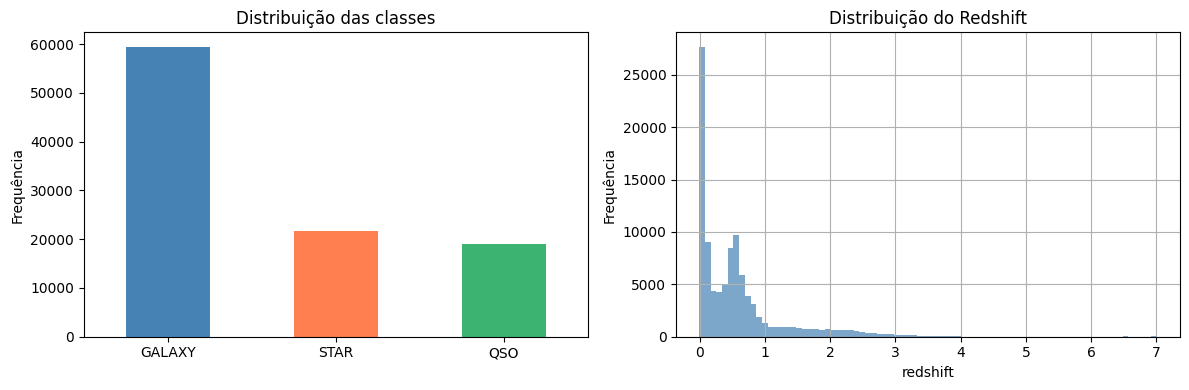

In [6]:
print(df['class'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral','mediumseagreen'])
axes[0].set_title('Distribuição das classes')
axes[0].set_xlabel(''); axes[0].set_ylabel('Frequência')
axes[0].tick_params(rotation=0)

df['redshift'].hist(bins=80, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Distribuição do Redshift')
axes[1].set_xlabel('redshift'); axes[1].set_ylabel('Frequência')

plt.tight_layout(); plt.show()


Observações retiradas:

- Há ~3x mais galáxias do que quasares. Vou corrigir isso com pesos de classe na loss;
- A distribuição tem uma cauda longa (principalmente quasares em redshifts altos). Aplicar **log1p** vai achatar isso e facilitar a aprendizagem da rede;
- Índices de cor (diferença entre bandas adjacentes do espectro eletromagnético)
são mais informativos que as magnitudes brutas porque capturam a forma do espectro, que é característica de cada tipo de objeto.

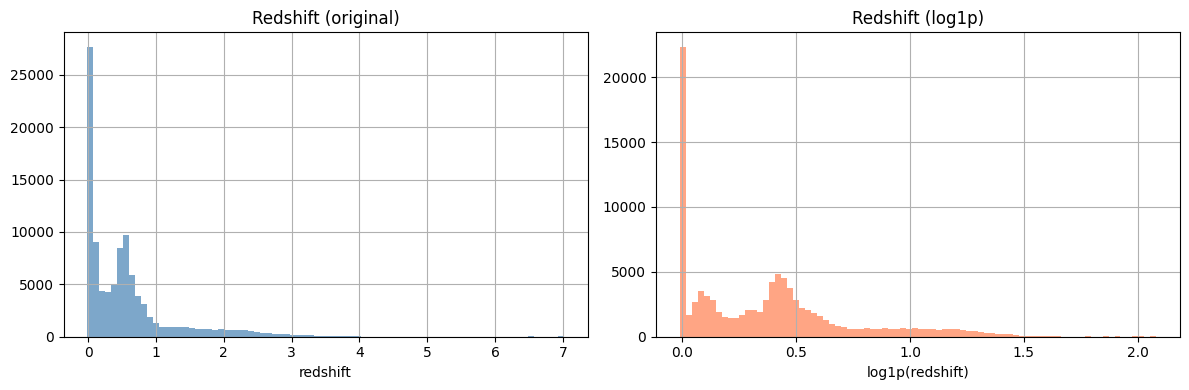

In [7]:
BANDAS = ['u', 'g', 'r', 'i', 'z']
ID_COLS = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
           'spec_obj_ID', 'fiber_ID', 'plate', 'MJD']

df = df[(df[BANDAS] > -100).all(axis=1)].copy()
df.drop(columns=[c for c in ID_COLS if c in df.columns], inplace=True)

df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']
df['redshift_log'] = np.where(df['redshift'] > 0, np.log1p(df['redshift']), df['redshift'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['redshift'].hist(bins=80, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Redshift (original)'); axes[0].set_xlabel('redshift')
df['redshift_log'].hist(bins=80, ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('Redshift (log1p)'); axes[1].set_xlabel('log1p(redshift)')
plt.tight_layout(); plt.show()


Aqui implemento boas práticas de MLOps: split 70/15/15 (para prevenção de data leakage) e pesos de classes.

In [8]:
FEATURES = ['u_g', 'g_r', 'r_i', 'i_z', 'redshift_log']
LABEL_MAP = {'GALAXY': 0, 'STAR': 1, 'QSO': 2}
CLASS_NAMES = ['Galaxy', 'Star', 'QSO']

X = df[FEATURES].values
y = df['class'].map(LABEL_MAP).values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pesos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_tensor = torch.tensor(pesos, dtype=torch.float32).to(device)

print(f"Treino: {len(X_train):,} | Val: {len(X_val):,} | Teste: {len(X_test):,}")
print(f"Pesos de classe: Galaxy={pesos[0]:.2f}, Star={pesos[1]:.2f}, QSO={pesos[2]:.2f}")


Treino: 69,999 | Val: 15,000 | Teste: 15,000
Pesos de classe: Galaxy=0.56, Star=1.54, QSO=1.76


In [9]:
class AstroDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(AstroDataset(X_train_s, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(AstroDataset(X_val_s,   y_val),   batch_size=256, shuffle=False)
test_loader = DataLoader(AstroDataset(X_test_s,  y_test),  batch_size=256, shuffle=False)


Para testar largura e profundidade com eficiência, vou integrar algumas técnicas utilizando duas classes (**FlexNet e ResidualBlock**) contendo **Batch Norm, GELU, Dropout e Residual Connections**. As funções dessas técnicas são basicamente para estabilizar e acelerar o treinamento, força a rede em aprender caminhos alternativos, regularização e evitar ***vanishing gradient***.

In [10]:
class FlexNet(nn.Module):
    def __init__(self, input_dim=5, largura=64, profundidade=2, p_dropout=0.3, residual=False):
        super().__init__()
        camadas = [nn.Linear(input_dim, largura), nn.BatchNorm1d(largura), nn.GELU(), nn.Dropout(p_dropout)]

        for _ in range(profundidade - 1):
            if residual:
                camadas.append(ResidualBlock(largura, p_dropout))
            else:
                camadas += [nn.Linear(largura, largura), nn.BatchNorm1d(largura), nn.GELU(), nn.Dropout(p_dropout)]

        camadas.append(nn.Linear(largura, 3))
        self.rede = nn.Sequential(*camadas)

    def forward(self, x): return self.rede(x)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.bloco = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim)
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.bloco(x))


# Loop de Treinamento

Em vez de treinar um número fixo de épocas e esperar que seja o certo, o treino para automaticamente quando o F1 de validação para de melhorar, e restaura os pesos do melhor momento. Além disso, em vez de só reduzir o LR quando trava, o algoritmo oscila ciclicamente subindo de volta periodicamente para mover o modelo fora de mínimos locais rasos.

In [11]:
def treino(modelo, epochs=80, lr=1e-3, weight_decay=1e-4, patience=10, verbose=True):
    criterion = nn.CrossEntropyLoss(weight=pesos_tensor)
    optimizer = optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    hist = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'lr': []}
    best_f1, best_state, sem_melhora = 0.0, None, 0

    for epoch in range(epochs):
        modelo.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(modelo(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        modelo.eval()
        val_loss, preds, targets = 0, [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = modelo(X_b)
                val_loss += criterion(out, y_b).item()
                preds.extend(torch.argmax(out, 1).cpu().numpy())
                targets.extend(y_b.cpu().numpy())

        f1 = f1_score(targets, preds, average='macro', zero_division=0)
        scheduler.step(epoch + val_loss / 10)

        hist['train_loss'].append(train_loss / len(train_loader))
        hist['val_loss'].append(val_loss / len(val_loader))
        hist['val_f1'].append(f1)
        hist['lr'].append(optimizer.param_groups[0]['lr'])

        if verbose and ((epoch+1) % 10 == 0 or epoch == 0):
            print(f"  Época {epoch+1:03d} | LR: {hist['lr'][-1]:.2e} | "
                  f"Train: {hist['train_loss'][-1]:.4f} | Val: {hist['val_loss'][-1]:.4f} | F1: {f1:.4f}")

        if f1 > best_f1 + 1e-4:
            best_f1 = f1
            best_state = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}
            sem_melhora = 0
        else:
            sem_melhora += 1
            if sem_melhora >= patience:
                if verbose: print(f"\n  Early stopping na época {epoch+1}. Melhor F1: {best_f1:.4f}")
                break

    modelo.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    hist['best_f1'] = best_f1
    return hist


# Experimento 1 - Profundidade vs Largura

Irei testar 4 configurações para entender os *tradeoffs* entre aumentar neurônios por camada (largura) vs aumentar o número de camadas (profundidade). A hipótese é que redes profundas aprendem representações hierárquicas melhor, mas ficam mais difíceis de treinar sem *skip connections*.

In [12]:
configs = {
    'Baseline   (64×1)' : dict(largura=64,  profundidade=1, residual=False),
    'Larga      (512×1)': dict(largura=512, profundidade=1, residual=False),
    'Profunda   (64×6)' : dict(largura=64,  profundidade=6, residual=True),
    'Balanceada (128×3)': dict(largura=128, profundidade=3, residual=True),
}

resultados = {}
for nome, cfg in configs.items():
    print(f"\n  {nome}")
    torch.manual_seed(SEED)
    modelo = FlexNet(input_dim=5, **cfg).to(device)
    resultados[nome] = treino(modelo, epochs=80, patience=10)


  Baseline   (64×1)
  Época 001 | LR: 9.11e-04 | Train: 0.4720 | Val: 0.3263 | F1: 0.8044
  Época 010 | LR: 1.00e-03 | Train: 0.2081 | Val: 0.1812 | F1: 0.9226
  Época 020 | LR: 5.09e-04 | Train: 0.1737 | Val: 0.1516 | F1: 0.9290
  Época 030 | LR: 1.13e-06 | Train: 0.1690 | Val: 0.1445 | F1: 0.9352
  Época 040 | LR: 8.59e-04 | Train: 0.1606 | Val: 0.1358 | F1: 0.9393

  Early stopping na época 43. Melhor F1: 0.9428

  Larga      (512×1)
  Época 001 | LR: 9.52e-04 | Train: 0.3400 | Val: 0.2396 | F1: 0.8742
  Época 010 | LR: 1.25e-06 | Train: 0.1745 | Val: 0.1526 | F1: 0.9365
  Época 020 | LR: 5.16e-04 | Train: 0.1583 | Val: 0.1367 | F1: 0.9397

  Early stopping na época 29. Melhor F1: 0.9477

  Profunda   (64×6)
  Época 001 | LR: 9.74e-04 | Train: 0.2697 | Val: 0.1764 | F1: 0.9362
  Época 010 | LR: 9.64e-04 | Train: 0.1402 | Val: 0.5842 | F1: 0.7764

  Early stopping na época 11. Melhor F1: 0.9362

  Balanceada (128×3)
  Época 001 | LR: 9.84e-04 | Train: 0.2252 | Val: 0.1382 | F1: 0.94

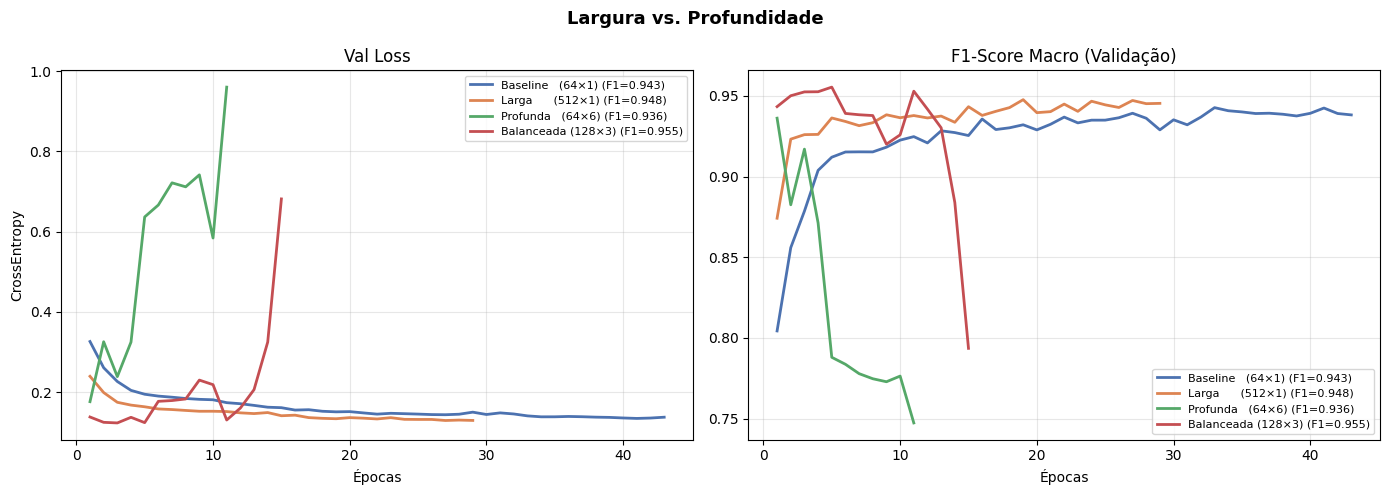

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Largura vs. Profundidade', fontsize=13, fontweight='bold')
cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (nome, hist), cor in zip(resultados.items(), cores):
    ep = range(1, len(hist['val_loss'])+1)
    axes[0].plot(ep, hist['val_loss'], label=f"{nome} (F1={hist['best_f1']:.3f})", color=cor, lw=2)
    axes[1].plot(ep, hist['val_f1'],  label=f"{nome} (F1={hist['best_f1']:.3f})", color=cor, lw=2)

axes[0].set_title('Val Loss'); axes[0].set_xlabel('Épocas'); axes[0].set_ylabel('CrossEntropy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title('F1-Score Macro (Validação)'); axes[1].set_xlabel('Épocas')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


Os resultados revelam padrões claros sobre como largura e profundidade afetam o aprendizado nesse problema.
A Baseline (64×1) convergiu lentamente mas de forma estável, precisando de 43 épocas antes do early stopping. É coerente, pois uma rede rasa com poucos neurônios tem capacidade limitada, aprende devagar, mas também não tem o que decorar.

A Rede Larga (512×1) superou a baseline e convergiu mais rápido (29 épocas). Aumentar a largura numa camada única permite capturar relações mais complexas entre as features sem o risco que vem com profundidade, o que explica tanto o ganho de performance quanto a estabilidade.

Já a Rede Profunda (64×6). Na época 10, a val loss já estava em 0.58 enquanto a train loss era 0.14, um gap que é a assinatura clássica de overfitting severo. O early stopping resgatou o F1 da época 1 (0.9362) antes do colapso total. O que aconteceu aqui é que, com apenas 64 neurônios por camada e 6 camadas empilhadas, a rede tem gargalos de representação em cada camada mas complexidade de parâmetros suficiente para memorizar o treino. As residual connections ajudam com o fluxo do gradiente, mas não resolvem o problema de capacidade insuficiente por camada.

A Rede Balanceada (128×3) atingiu o melhor resultado (F1 = 0.9555) em apenas 15 épocas, sugerindo que encontrou o ponto ideal para esse dataset: capacidade suficiente para aprender as fronteiras de decisão sem excesso de profundidade que leve ao overfitting.

# Experimento 2 - Overfitting e Regularização

Vou estressar a configuração com diferentes taxas de *dropout* para observar cada regime:

- **Underfitting**: *train loss* alta e *val loss* alta  
- **Bom**: train próximo de val e ambas baixas (ponto ideal);
- **Overfitting**: *val loss* sobe enquanto *train loss* cai.

In [16]:
configs_reg = {
    'Sem regularização (p=0.0)': 0.0,
    'Dropout leve      (p=0.1)': 0.1,
    'Dropout moderado  (p=0.3)': 0.3,
    'Dropout agressivo (p=0.5)': 0.5,
}

res_reg = {}
for nome, p in configs_reg.items():
    print(f"\n  {nome}")
    torch.manual_seed(SEED)
    m = FlexNet(largura=128, profundidade=3, p_dropout=p, residual=True).to(device)
    res_reg[nome] = treino(m, epochs=80, patience=12)



  Sem regularização (p=0.0)
  Época 001 | LR: 9.87e-04 | Train: 0.1477 | Val: 0.1250 | F1: 0.9445
  Época 010 | LR: 7.11e-06 | Train: 0.0871 | Val: 0.0850 | F1: 0.9640
  Época 020 | LR: 5.39e-04 | Train: 0.0868 | Val: 0.0868 | F1: 0.9671
  Época 030 | LR: 1.92e-06 | Train: 0.0775 | Val: 0.1041 | F1: 0.9670
  Época 040 | LR: 8.67e-04 | Train: 0.0850 | Val: 0.0875 | F1: 0.9689
  Época 050 | LR: 5.19e-04 | Train: 0.0779 | Val: 0.0909 | F1: 0.9674

  Early stopping na época 52. Melhor F1: 0.9689

  Dropout leve      (p=0.1)
  Época 001 | LR: 9.84e-04 | Train: 0.1764 | Val: 0.1363 | F1: 0.9400
  Época 010 | LR: 5.58e-06 | Train: 0.1068 | Val: 0.0964 | F1: 0.9617
  Época 020 | LR: 5.32e-04 | Train: 0.1011 | Val: 0.1024 | F1: 0.9607

  Early stopping na época 27. Melhor F1: 0.9634

  Dropout moderado  (p=0.3)
  Época 001 | LR: 9.84e-04 | Train: 0.2252 | Val: 0.1382 | F1: 0.9434
  Época 010 | LR: 9.99e-04 | Train: 0.1257 | Val: 0.2188 | F1: 0.9259

  Early stopping na época 17. Melhor F1: 0.9

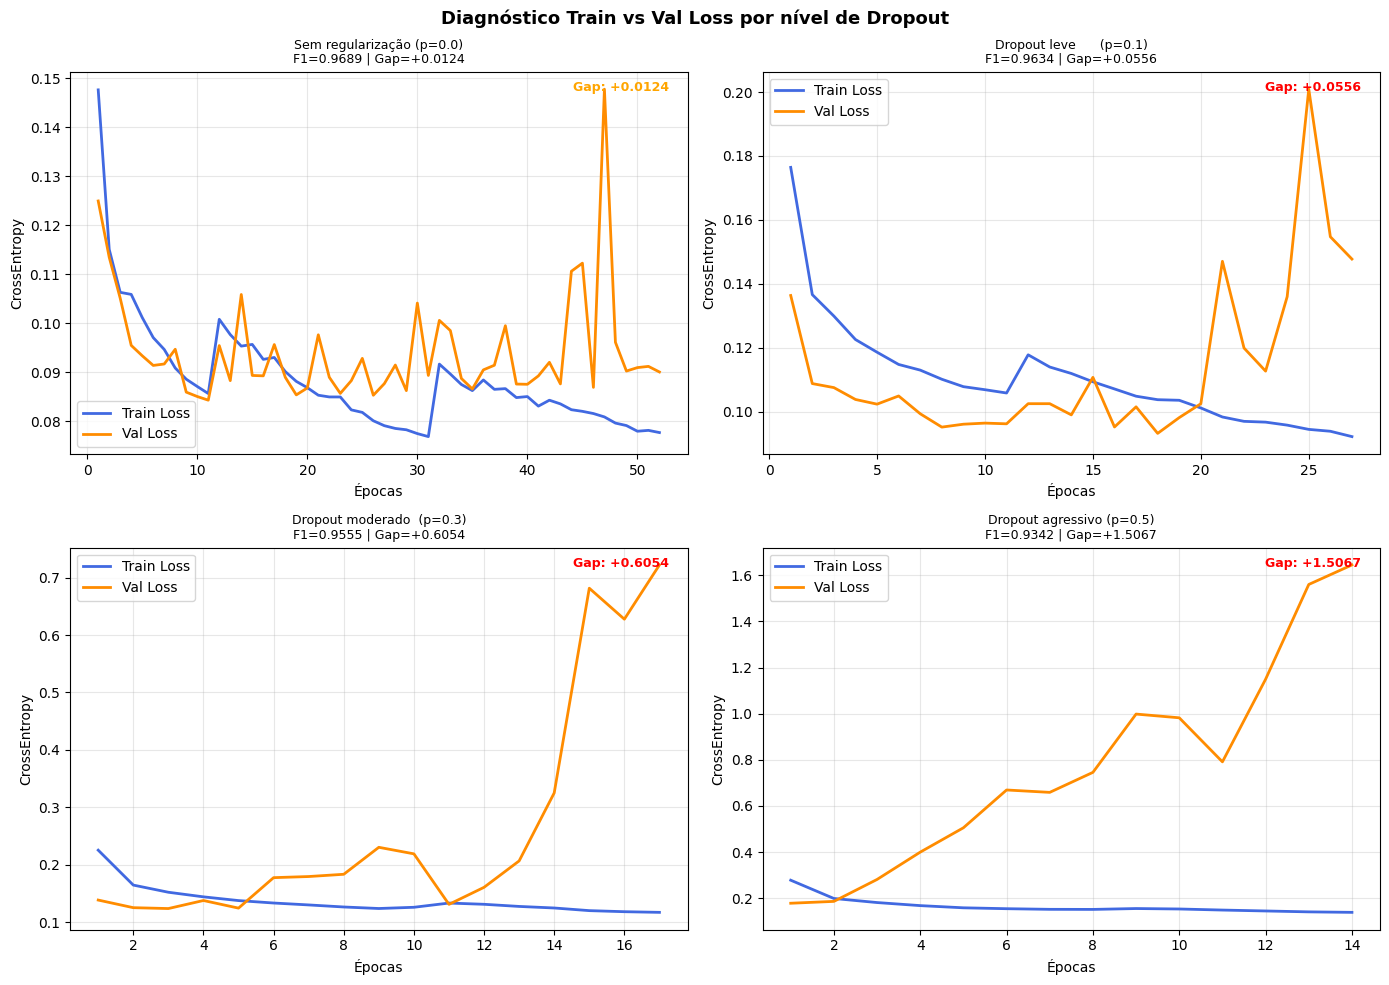

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnóstico Train vs Val Loss por nível de Dropout', fontsize=13, fontweight='bold')

for ax, (nome, hist) in zip(axes.flat, res_reg.items()):
    ep = range(1, len(hist['train_loss'])+1)
    ax.plot(ep, hist['train_loss'], label='Train Loss', color='royalblue', lw=2)
    ax.plot(ep, hist['val_loss'],   label='Val Loss',   color='darkorange', lw=2)
    gap = hist['val_loss'][-1] - hist['train_loss'][-1]
    ax.set_title(f"{nome}\nF1={hist['best_f1']:.4f} | Gap={gap:+.4f}", fontsize=9)
    ax.set_xlabel('Épocas'); ax.set_ylabel('CrossEntropy')
    ax.legend(); ax.grid(alpha=0.3)
    cor_gap = 'red' if gap > 0.02 else ('orange' if gap > 0.005 else 'green')
    ax.annotate(f'Gap: {gap:+.4f}', xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', fontsize=9, color=cor_gap, fontweight='bold')

plt.tight_layout(); plt.show()


O experimento de regularização produziu um resultado contraintuitivo que vale destacar: a rede sem dropout algum obteve o melhor F1 (0.9689), superando todas as versões regularizadas.


# Experimento 3 - Otimização de hiperparâmetros com Optuna

Os experimentos anteriores foram exploratórios e manual. O Optuna resolve isso com busca bayesiana (TPE).

In [18]:
def objective(trial):
    largura      = trial.suggest_categorical('largura',      [64, 128, 256, 512])
    profundidade = trial.suggest_int('profundidade',         2, 5)
    p_dropout    = trial.suggest_float('p_dropout',          0.05, 0.4, step=0.05)
    lr           = trial.suggest_float('lr',                 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay',       1e-5, 1e-2, log=True)

    torch.manual_seed(SEED + trial.number)
    modelo = FlexNet(largura=largura, profundidade=profundidade,
                     p_dropout=p_dropout, residual=True).to(device)
    hist = treino(modelo, epochs=60, lr=lr, weight_decay=weight_decay,
                   patience=8, verbose=False)
    return hist['best_f1']

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nMelhores hiperparâmetros:")
for k, v in study.best_params.items(): print(f"  {k}: {v}")
print(f"    Melhor F1-Val: {study.best_value:.4f}")


  0%|          | 0/40 [00:00<?, ?it/s]


Melhores hiperparâmetros:
  largura: 512
  profundidade: 2
  p_dropout: 0.25
  lr: 0.005343292273126008
  weight_decay: 0.00015219123698520932
    Melhor F1-Val: 0.9681


O Optuna encontrou uma configuração robusta, mas com 40 trials não há garantia de que é o ótimo global.

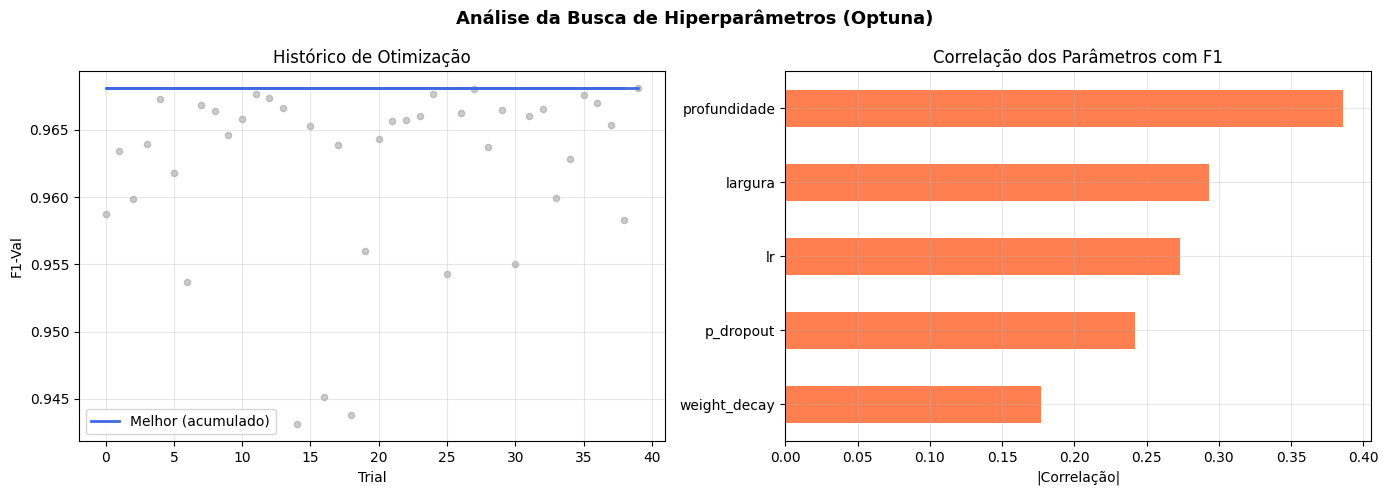


Melhores configurações encontradas:
       value  params_largura  params_lr  params_p_dropout  \
39  0.968096             512   0.005343              0.25   
27  0.968054             256   0.004009              0.35   
11  0.967687              64   0.007833              0.20   
24  0.967624             256   0.003906              0.05   
35  0.967594             128   0.008025              0.20   

    params_profundidade  params_weight_decay  
39                    2             0.000152  
27                    2             0.000672  
11                    3             0.000195  
24                    3             0.001495  
35                    2             0.000358  


In [24]:
trials_df = study.trials_dataframe().sort_values('value', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise da Busca de Hiperparâmetros (Optuna)', fontsize=13, fontweight='bold')

axes[0].plot(trials_df.index, trials_df['value'].cummax(), color='royalblue', lw=2, label='Melhor (acumulado)')
axes[0].scatter(range(len(trials_df)), trials_df.sort_index()['value'], alpha=0.4, s=20, color='gray')
axes[0].set_title('Histórico de Otimização'); axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1-Val'); axes[0].legend(); axes[0].grid(alpha=0.3)

param_cols = [c for c in trials_df.columns if c.startswith('params_')]
importancias = {c.replace('params_', ''): trials_df[c].corr(trials_df['value']).round(3)
                for c in param_cols if trials_df[c].dtype in ['float64', 'int64']}
pd.Series(importancias).abs().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Correlação dos Parâmetros com F1'); axes[1].set_xlabel('|Correlação|')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\nMelhores configurações encontradas:")
print(trials_df[['value'] + param_cols].head())


# Modelo Final

Com os melhores hiperparâmetros identificados pelo Optuna, trei o modelo final por mais épocas. Agora vamos também monitorar a curva do *Learning Rate* junto com o F1 para ver o efeito do *Cosine Annealing*.

In [20]:
best = study.best_params
torch.manual_seed(SEED)

model_final = FlexNet(
    largura=best['largura'], profundidade=best['profundidade'],
    p_dropout=best['p_dropout'], residual=True
).to(device)

n_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
print(f"Arquitetura final: {best['largura']}×{best['profundidade']} | dropout={best['p_dropout']} | params={n_params:,}")

hist_final = treino(model_final, epochs=120, lr=best['lr'],
                     weight_decay=best['weight_decay'], patience=15)


Arquitetura final: 512×2 | dropout=0.25 | params=532,995
  Época 001 | LR: 5.25e-03 | Train: 0.1885 | Val: 0.1432 | F1: 0.9393
  Época 010 | LR: 2.69e-05 | Train: 0.1023 | Val: 0.0943 | F1: 0.9612
  Época 020 | LR: 2.87e-03 | Train: 0.0974 | Val: 0.0884 | F1: 0.9658
  Época 030 | LR: 9.43e-06 | Train: 0.0879 | Val: 0.0837 | F1: 0.9671
  Época 040 | LR: 4.63e-03 | Train: 0.0942 | Val: 0.0905 | F1: 0.9677
  Época 050 | LR: 2.78e-03 | Train: 0.0901 | Val: 0.0859 | F1: 0.9675

  Early stopping na época 57. Melhor F1: 0.9687


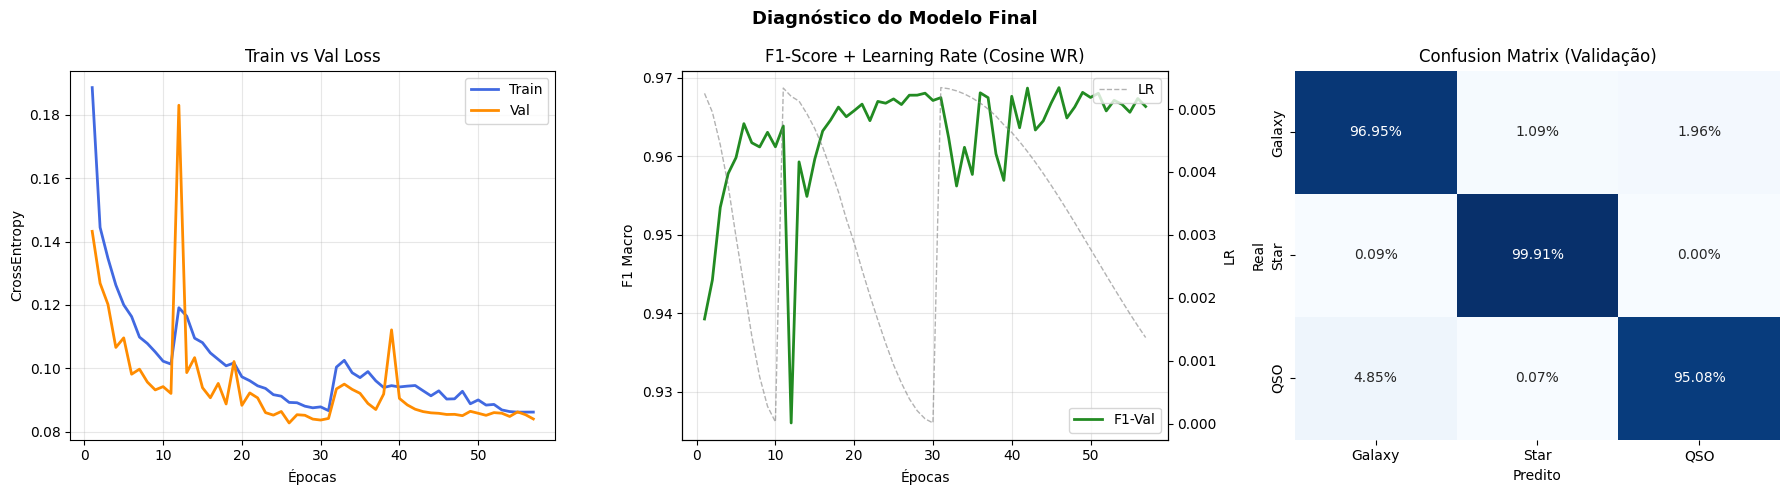

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnóstico do Modelo Final', fontsize=13, fontweight='bold')
ep = range(1, len(hist_final['train_loss'])+1)

axes[0].plot(ep, hist_final['train_loss'], label='Train', color='royalblue', lw=2)
axes[0].plot(ep, hist_final['val_loss'],   label='Val',   color='darkorange', lw=2)
axes[0].set_title('Train vs Val Loss'); axes[0].set_xlabel('Épocas'); axes[0].set_ylabel('CrossEntropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

ax_lr = axes[1].twinx()
axes[1].plot(ep, hist_final['val_f1'], color='forestgreen', lw=2, label='F1-Val')
ax_lr.plot(ep, hist_final['lr'], color='gray', lw=1, linestyle='--', alpha=0.6, label='LR')
axes[1].set_title('F1-Score + Learning Rate (Cosine WR)')
axes[1].set_xlabel('Épocas'); axes[1].set_ylabel('F1 Macro'); ax_lr.set_ylabel('LR')
axes[1].legend(loc='lower right'); ax_lr.legend(loc='upper right'); axes[1].grid(alpha=0.3)

model_final.eval()
preds_val, targets_val = [], []
with torch.no_grad():
    for X_b, y_b in val_loader:
        out = model_final(X_b.to(device))
        preds_val.extend(torch.argmax(out, 1).cpu().numpy())
        targets_val.extend(y_b.numpy())

cm = confusion_matrix(targets_val, preds_val, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Galaxy','Star','QSO'], yticklabels=['Galaxy','Star','QSO'],
            ax=axes[2], cbar=False)
axes[2].set_title('Confusion Matrix (Validação)'); axes[2].set_ylabel('Real'); axes[2].set_xlabel('Predito')

plt.tight_layout(); plt.show()


O modelo final, treinado com os hiperparâmetros encontrados pelo Optuna, atingiu F1 Macro de **0.9687** na validação, praticamente idêntico ao melhor trial da busca (0.9681).

A curva de treinamento mostra um comportamento saudável: *train loss* e *val loss* caem juntas e permanecem próximas ao longo de todas as 57 épocas, sem sinais de overfitting. O efeito do *Cosine Annealing* com *Warm Restarts* é visível nas oscilações do LR, há uma elevação temporária na loss antes de retomar a queda, exatamente o comportamento esperado do *scheduler* ao tentar escapar de mínimos locais.

# Avaliação Final

In [22]:
model_final.eval()
preds_test, targets_test = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model_final(X_b.to(device))
        preds_test.extend(torch.argmax(out, 1).cpu().numpy())
        targets_test.extend(y_b.numpy())

f1_teste = f1_score(targets_test, preds_test, average='macro')
print(f"F1-Score Macro no Teste: {f1_teste:.4f}\n")
print(classification_report(targets_test, preds_test, target_names=['Galaxy', 'Star', 'QSO'], digits=4))


F1-Score Macro no Teste: 0.9655

              precision    recall  f1-score   support

      Galaxy     0.9806    0.9683    0.9744      8917
        Star     0.9788    0.9985    0.9885      3239
         QSO     0.9260    0.9413    0.9336      2844

    accuracy                         0.9697     15000
   macro avg     0.9618    0.9693    0.9655     15000
weighted avg     0.9698    0.9697    0.9697     15000



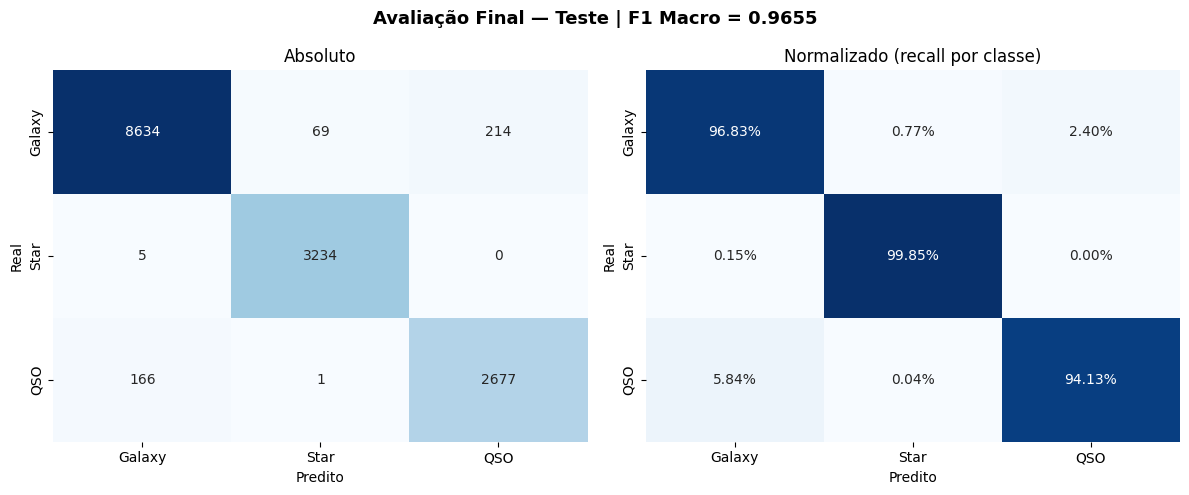

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Avaliação Final — Teste | F1 Macro = {f1_teste:.4f}', fontsize=13, fontweight='bold')

cm_abs  = confusion_matrix(targets_test, preds_test)
cm_norm = confusion_matrix(targets_test, preds_test, normalize='true')
nomes = ['Galaxy', 'Star', 'QSO']

sns.heatmap(cm_abs,  annot=True, fmt='d',    cmap='Blues', xticklabels=nomes, yticklabels=nomes, ax=axes[0], cbar=False)
axes[0].set_title('Absoluto'); axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

sns.heatmap(cm_norm, annot=True, fmt='.2%',  cmap='Blues', xticklabels=nomes, yticklabels=nomes, ax=axes[1], cbar=False)
axes[1].set_title('Normalizado (recall por classe)'); axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predito')

plt.tight_layout(); plt.show()


A avaliação no conjunto de teste, confirma a capacidade de generalização do modelo com **F1 = 0.9655**, apenas 0.003 abaixo do resultado de validação. Essa proximidade indica que o modelo não decorou os dados de treino e que as decisões de hiperparâmetros não foram enviesadas pelo conjunto de validação.

Analisando por classe, estrelas obtiveram o melhor desempenho (**F1 = 0.9885**), com recall de 0.9985. O de galáxias também foi bom (**F1 = 0.9744**), com precision alta (0.9806), o que significa poucos falsos positivos. Quasares foram a classe mais difícil (**F1 = 0.9336**), mesmo após a correção com pesos de classe.